In [4]:
import soccerdata as sd

# Inicializamos Understat para la Serie A
# Nota: Understat usa el año de inicio (2024 para la temporada 24/25)
understat = sd.Understat(leagues="ITA-Serie A", seasons="2024")

try:
    # Esta es la función correcta para traer los datos de los equipos en Understat
    df_serie_a = understat.read_leagues()
    
    print("¡TABLA CONSEGUIDA! Datos de Understat:")
    display(df_serie_a.head())
    
except Exception as e:
    print(f"Error con Understat: {e}")
    # Si read_leagues falla, probemos con las estadísticas por situación de juego
    print("\nIntentando con estadísticas de situación...")
    display(understat.read_situations().head())

[04/02/26 23:19:48] INFO     Saving cached data to C:\Users\israe\soccerdata\data\Understat          ]8;id=102027;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=837789;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

[2026-04-02 23:19:48] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: C:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


                    INFO     Successfully loaded TLS library:                                      ]8;id=916035;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\tls_requests\models\libraries.py\libraries.py]8;;\:]8;id=791939;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\tls_requests\models\libraries.py#397\397]8;;\
                             C:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packa                 
                             ges\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll                          

¡TABLA CONSEGUIDA! Datos de Understat:


,league_id,url
league,,
ITA-Serie A,2,https://understat.com/league/Serie_A


In [5]:
import soccerdata as sd

# Inicializamos
understat = sd.Understat(leagues="ITA-Serie A", seasons="2026")

try:
    # 1. Leemos la tabla
    df_serie_a = understat.read_leagues()
    
    # 2. Vemos qué columnas trajo realmente para que no nos de error
    print("Columnas encontradas:", df_serie_a.columns.tolist())
    
    # 3. Mostramos todo el DataFrame (Pandas en el Notebook te dejará scrollear)
    display(df_serie_a.head(10))
    
except Exception as e:
    print(f"Error: {e}")

[04/02/26 23:20:00] INFO     Saving cached data to C:\Users\israe\soccerdata\data\Understat          ]8;id=865821;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=870472;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

Columnas encontradas: ['league_id', 'url']


,league_id,url
league,,
ITA-Serie A,2,https://understat.com/league/Serie_A


In [6]:
import soccerdata as sd

# Inicializamos (Temporada 2025 para la actual 25/26)
understat = sd.Understat(leagues="ITA-Serie A", seasons="2025")

try:
    # CAMBIO CLAVE: Usamos read_league_table() en lugar de read_leagues()
    df_tabla = understat.read_league_table()
    
    # Reseteamos el índice para que 'team' sea una columna fácil de filtrar
    df_tabla = df_tabla.reset_index()
    
    # Buscamos al Como
    como = df_tabla[df_tabla['team'].str.contains('Como', case=False)].copy()

    if not como.empty:
        print("--- DATOS DE RENDIMIENTO: COMO 1907 ---")
        # Understat suele usar 'xg' y 'goals' (o 'scored')
        display(como[['team', 'wins', 'draws', 'losses', 'pts', 'xg', 'scored']])
    else:
        print("No encontré al Como. Aquí tienes los equipos que bajaron:")
        print(df_tabla['team'].unique())

except Exception as e:
    print(f"Error al leer la tabla: {e}")
    # Si falla, vamos a ver qué funciones tiene permitidas tu objeto understat
    print("\nFunciones disponibles:", [m for m in dir(understat) if 'read' in m])

[04/02/26 23:20:10] INFO     Saving cached data to C:\Users\israe\soccerdata\data\Understat          ]8;id=976847;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=553636;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

Error al leer la tabla: 'Understat' object has no attribute 'read_league_table'

Funciones disponibles: ['_read_league_season', '_read_leagues', '_read_match', 'read_leagues', 'read_player_match_stats', 'read_player_season_stats', 'read_schedule', 'read_seasons', 'read_shot_events', 'read_team_match_stats']


In [ ]:
import soccerdata as sd
import pandas as pd

# 1. Inicializamos con la temporada actual
understat = sd.Understat(leagues="ITA-Serie A", seasons="2025")

try:
    # 2. Usamos la función de jugadores
    df_players = understat.read_player_season_stats()
    
    # 3. Reseteamos el índice para que 'team' sea una columna normal
    df_players = df_players.reset_index()
    
    # 4. Buscamos al Como (ignorando mayúsculas/minúsculas)
    como_stats = df_players[df_players['team'].str.contains('Como', case=False)].copy()

    if not como_stats.empty:
        print(f"--- PLANTILLA Y RENDIMIENTO: {como_stats['team'].iloc[0]} ---")
        
        # Agrupamos por equipo para tener los totales (Goles y xG)
        como_total = como_stats.groupby('team').agg({
            'goals': 'sum',
            'xg': 'sum',
            'assists': 'sum',
            'key_passes': 'sum'
        })
        
        como_total['eficiencia'] = como_total['goals'] - como_total['xg']
        display(como_total)
        
        print("\n--- TOP 5 JUGADORES DEL COMO (por xG) ---")
        display(como_stats[['player', 'goals', 'xg', 'assists']].sort_values('xg', ascending=False).head(5))
    else:
        print("Equipos detectados:")
        print(df_players['team'].unique())

except Exception as e:
    print(f"Error definitivo: {e}")
    # Si falla 'team', vemos qué nombres de columnas hay
    if 'df_players' in locals():
        print("Columnas disponibles:", df_players.columns.tolist())

[04/02/26 23:20:17] INFO     Saving cached data to C:\Users\israe\soccerdata\data\Understat          ]8;id=184413;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=649077;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

--- PLANTILLA Y RENDIMIENTO: Como ---


,goals,xg,assists,key_passes,eficiencia
team,,,,,
Como,52,54.832341,39,334,-2.832341



--- TOP 5 JUGADORES DEL COMO (por xG) ---


,player,goals,xg,assists
129,Tasos Douvikas,11,11.378991,1
125,Nico Paz,10,8.010857,6
119,Lucas Da Cunha,3,4.579114,3
131,Álvaro Morata,0,4.535538,1
115,Jacobo Ramón,2,3.904356,0


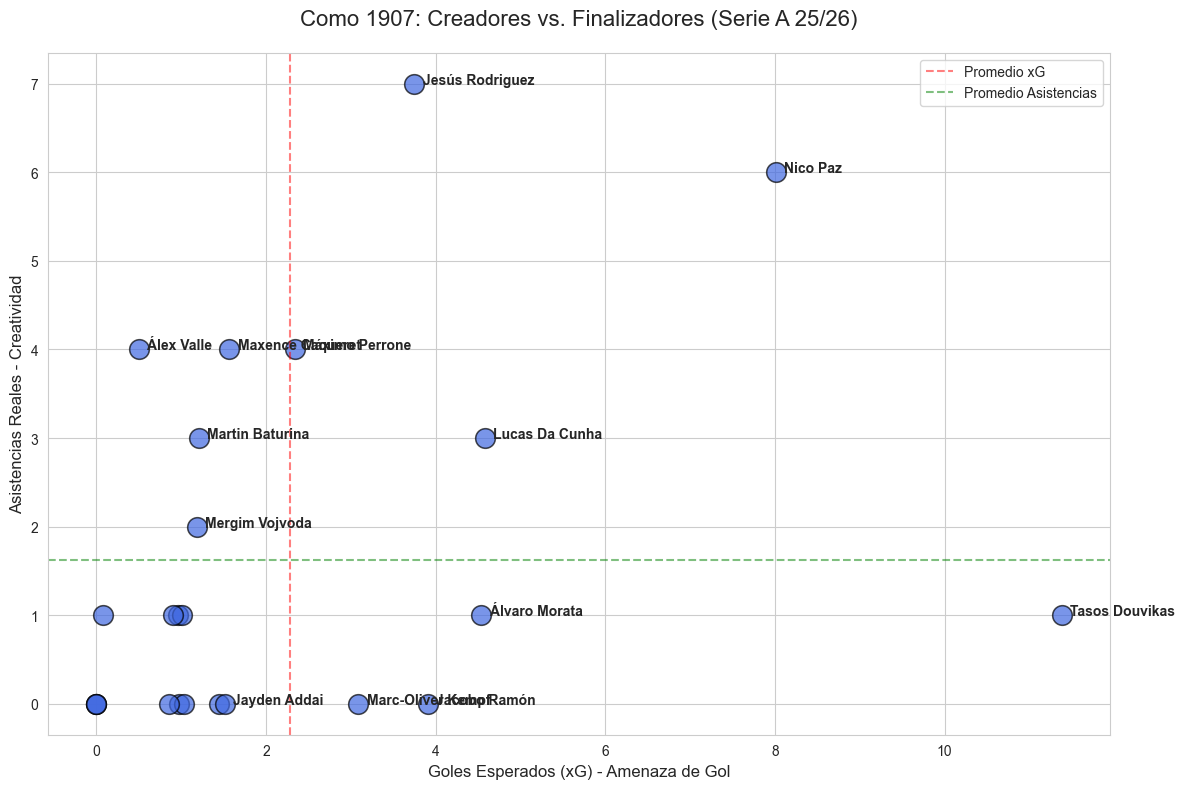

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Creamos el scatter plot
# x = xG (Peligro generado), y = Asistencias (Creación de gol)
ax = sns.scatterplot(data=como_stats, x='xg', y='assists', s=200, color='royalblue', edgecolor='black', alpha=0.7)

# Añadimos los nombres de los jugadores
for i in range(como_stats.shape[0]):
    # Solo etiquetamos a los que tienen relevancia para que no se amontonen
    if como_stats.xg.iloc[i] > 1.5 or como_stats.assists.iloc[i] > 1:
        plt.text(como_stats.xg.iloc[i] + 0.1, como_stats.assists.iloc[i], 
                 como_stats.player.iloc[i], fontsize=10, weight='bold')

# Personalización estética
plt.title('Como 1907: Creadores vs. Finalizadores (Serie A 25/26)', fontsize=16, pad=20)
plt.xlabel('Goles Esperados (xG) - Amenaza de Gol', fontsize=12)
plt.ylabel('Asistencias Reales - Creatividad', fontsize=12)

# Líneas promedio para crear cuadrantes
plt.axvline(como_stats.xg.mean(), color='red', linestyle='--', alpha=0.5, label='Promedio xG')
plt.axhline(como_stats.assists.mean(), color='green', linestyle='--', alpha=0.5, label='Promedio Asistencias')

plt.legend()
plt.tight_layout()
plt.show()

[04/02/26 23:21:02] WARNING  C:\Users\israe\AppData\Local\Temp\ipykernel_12360\611428810.py:22:     ]8;id=252440;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=591222;file://c:\Users\israe\AppData\Local\Programs\Python\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `y` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(data=df_liga_eficiencia, x='eficiencia', y='team',                      
                             palette=colors, edgecolor='black')                                                    
                                                                                                                   

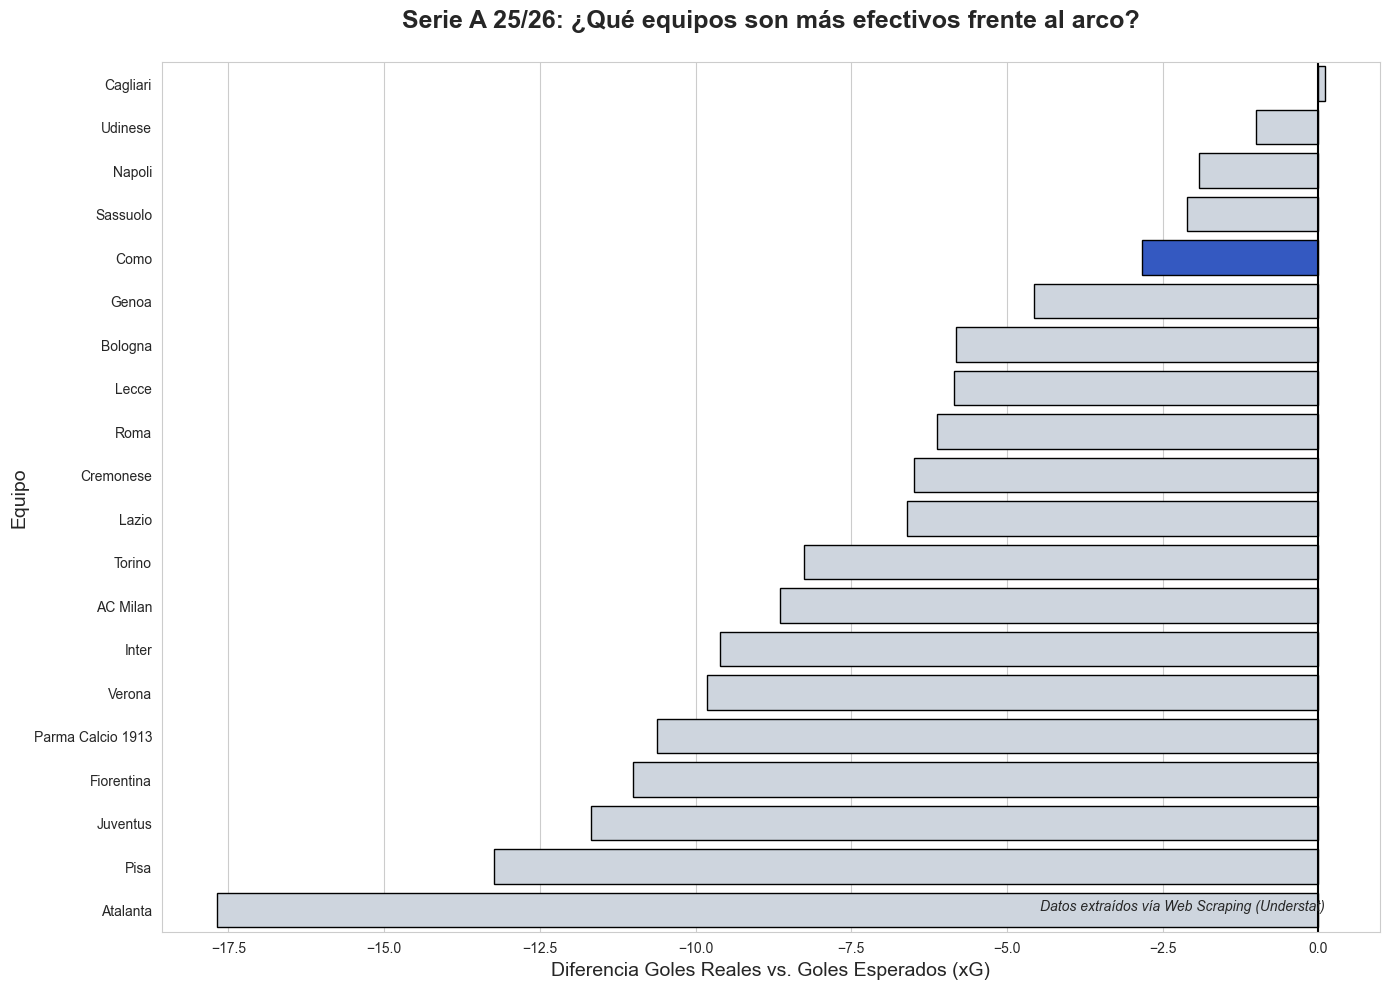

Eficiencia del Como: -2.83


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # 1. Agrupamos los datos de los jugadores por equipo para tener el total de la liga
    # Usamos 'goals' porque es el nombre que Understat da en la tabla de jugadores
    df_liga_eficiencia = df_players.groupby('team').agg({
        'goals': 'sum',
        'xg': 'sum'
    }).reset_index()

    # 2. Calculamos la eficiencia (Goles - xG)
    df_liga_eficiencia['eficiencia'] = df_liga_eficiencia['goals'] - df_liga_eficiencia['xg']
    df_liga_eficiencia = df_liga_eficiencia.sort_values('eficiencia', ascending=False)

    # 3. Visualización
    plt.figure(figsize=(14, 10))
    
    # Resaltamos al Como en azul y el resto en gris
    colors = ['#1d4ed8' if 'Como' in t else '#cbd5e1' for t in df_liga_eficiencia['team']]
    
    sns.barplot(data=df_liga_eficiencia, x='eficiencia', y='team', palette=colors, edgecolor='black')

    # 4. Estética profesional para LinkedIn
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    plt.title('Serie A 25/26: ¿Qué equipos son más efectivos frente al arco?', fontsize=18, pad=25, weight='bold')
    plt.xlabel('Diferencia Goles Reales vs. Goles Esperados (xG)', fontsize=14)
    plt.ylabel('Equipo', fontsize=14)
    
    # Añadimos una nota explicativa
    plt.text(df_liga_eficiencia['eficiencia'].max(), len(df_liga_eficiencia)-1, 
             'Datos extraídos vía Web Scraping (Understat)', 
             fontsize=10, style='italic', ha='right')

    plt.tight_layout()
    plt.show()

    # 5. Confirmación para tu post
    como_final = df_liga_eficiencia[df_liga_eficiencia['team'].str.contains('Como')]
    print(f"Eficiencia del Como: {como_final['eficiencia'].values[0]:.2f}")

except Exception as e:
    print(f"Error técnico en el gráfico: {e}")
    print("Columnas disponibles para agrupar:", df_players.columns.tolist())